**CREDIT CARD FRAUD DETECTION**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE


In [ ]:
df = pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [ ]:
df.shape

(13954, 31)

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13954 entries, 0 to 13953
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    13954 non-null  int64  
 1   V1      13954 non-null  float64
 2   V2      13954 non-null  float64
 3   V3      13954 non-null  float64
 4   V4      13954 non-null  float64
 5   V5      13954 non-null  float64
 6   V6      13954 non-null  float64
 7   V7      13954 non-null  float64
 8   V8      13954 non-null  float64
 9   V9      13954 non-null  float64
 10  V10     13954 non-null  float64
 11  V11     13954 non-null  float64
 12  V12     13954 non-null  float64
 13  V13     13954 non-null  float64
 14  V14     13954 non-null  float64
 15  V15     13954 non-null  float64
 16  V16     13954 non-null  float64
 17  V17     13954 non-null  float64
 18  V18     13954 non-null  float64
 19  V19     13954 non-null  float64
 20  V20     13954 non-null  float64
 21  V21     13954 non-null  float64
 22

In [ ]:
df.duplicated().sum()

np.int64(53)

In [ ]:
df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0.0
35,26,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0.0
113,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
114,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
115,74,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
221,145,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0
223,145,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0.0
1178,919,0.904289,-0.538055,0.396058,0.500680,-0.864473,-0.657199,0.027231,-0.029473,0.265447,...,-0.099460,-0.597579,-0.048666,0.551824,0.182934,0.402176,-0.081357,0.027252,158.00,0.0
1180,919,1.207596,-0.036860,0.572104,0.373148,-0.709633,-0.713698,-0.181105,0.011277,0.283940,...,-0.194591,-0.514717,0.089714,0.543768,0.240581,0.418921,-0.051693,-0.000085,1.00,0.0
1382,1074,-2.248488,-0.195670,0.026949,-0.525780,-0.238759,-0.033359,0.162196,0.928520,-0.424215,...,-0.032208,-0.745757,-0.243193,-0.821633,-0.030402,0.335838,-0.286998,-0.243768,158.00,0.0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(13901, 31)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,...,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13901.000000,13900.000000,13900.000000
mean,10132.095245,-0.232840,0.281483,0.846450,0.300122,-0.118347,0.125497,-0.156140,-0.014682,0.989314,...,-0.070498,-0.156265,-0.035962,0.012080,0.116952,0.036461,0.014107,0.002193,64.030378,0.004029
std,7734.602422,1.718300,1.393691,1.563379,1.501822,1.290997,1.320997,1.239432,1.255446,1.214144,...,0.864928,0.620866,0.500231,0.586796,0.427916,0.558649,0.392189,0.255756,178.189809,0.063347
min,0.000000,-27.670569,-34.607649,-24.667741,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-7.175097,...,-11.468435,-8.593642,-19.254328,-2.512377,-4.781606,-1.338556,-7.976100,-3.575312,0.000000,0.000000
25%,2998.000000,-0.967606,-0.283766,0.407857,-0.625913,-0.716347,-0.625692,-0.613949,-0.181932,0.288704,...,-0.271435,-0.547934,-0.173916,-0.338865,-0.136385,-0.374495,-0.076831,-0.014884,5.490000,0.000000
50%,9140.000000,-0.319024,0.252569,0.961790,0.218372,-0.190172,-0.147628,-0.111763,0.016665,0.971970,...,-0.132273,-0.121844,-0.045092,0.060931,0.154804,-0.034399,-0.000983,0.016193,15.820000,0.000000
75%,17110.000000,1.162962,0.882742,1.608281,1.193083,0.351077,0.505630,0.422208,0.264876,1.653402,...,0.018418,0.229071,0.069469,0.392837,0.393032,0.375760,0.098500,0.072272,52.392500,0.000000
max,24759.000000,1.960497,10.558600,4.101716,11.927512,34.099309,21.393069,34.303177,10.535558,10.392889,...,22.614889,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,13844
1.0,56


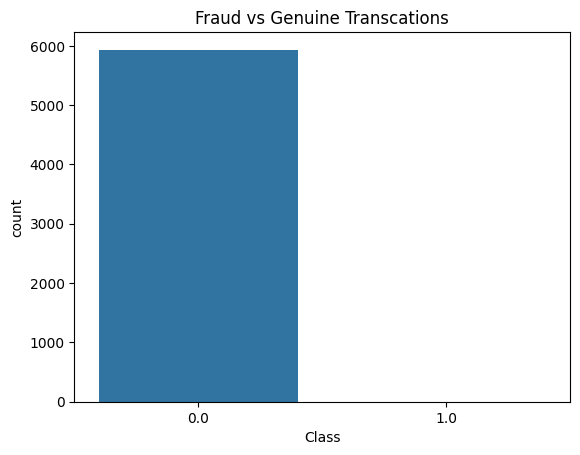

In [ ]:
sns.countplot(x ='Class' ,data = df)
plt.title("Fraud vs Genuine Transcations")
plt.show()

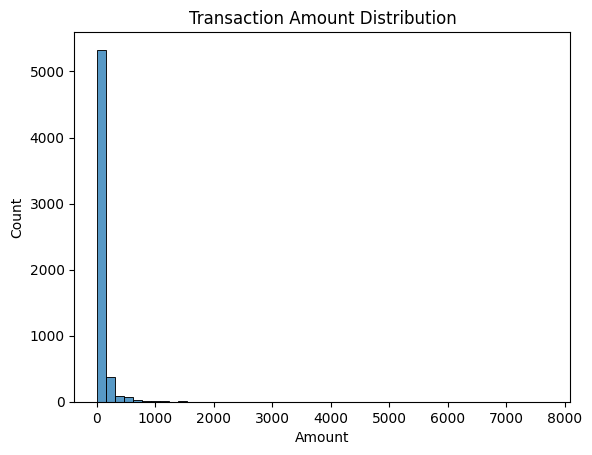

In [ ]:
sns.histplot(df['Amount'],bins = 50)
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000,...,5937.000000,5937.000000,5937.000000,5937.000000,5937.000000,5937.000000,5937.000000,5937.000000,5.937000e+03,5937.000000
mean,0.000000,-0.262299,0.282746,0.844354,0.100176,0.000912,0.191295,0.019414,-0.042185,0.395798,...,-0.042510,-0.160591,-0.036352,0.031030,0.089439,-0.039810,0.026236,0.006435,5.026578e-17,0.000505
std,1.000084,1.394252,1.210404,1.032617,1.444311,1.187438,1.366672,1.061111,1.305409,1.049022,...,0.885445,0.646916,0.374119,0.619004,0.408295,0.488795,0.362967,0.264978,1.000084e+00,0.022475
min,-1.518946,-12.168192,-15.732974,-12.389545,-4.657545,-32.092129,-7.465603,-12.968670,-23.632502,-3.336805,...,-11.468435,-8.454599,-7.996811,-2.512377,-2.322906,-1.338556,-7.976100,-2.909294,-3.384311e-01,0.000000
25%,-0.859563,-1.010005,-0.283893,0.295701,-0.845476,-0.607998,-0.681493,-0.490447,-0.190127,-0.265425,...,-0.259713,-0.593527,-0.187413,-0.345598,-0.154344,-0.399441,-0.049186,-0.017776,-3.154270e-01,0.000000
50%,-0.077819,-0.417580,0.344690,0.888377,0.157542,-0.083455,-0.150590,0.043992,0.037457,0.360673,...,-0.111616,-0.176099,-0.046727,0.096614,0.105752,-0.078569,0.015976,0.019379,-2.568285e-01,0.000000
75%,0.626175,1.116292,0.938975,1.504585,1.066811,0.438348,0.599657,0.565963,0.341262,0.962473,...,0.059915,0.273829,0.088505,0.436787,0.355631,0.244972,0.154984,0.082799,-4.233000e-02,0.000000
max,2.245318,1.685314,7.467017,4.101716,6.013346,10.658654,21.393069,34.303177,3.877662,9.272376,...,22.580675,4.393846,4.095021,3.200201,1.972515,3.463246,3.852046,4.860769,3.962061e+01,1.000000


In [ ]:
X = df.drop('Class',axis = 1)
y = df['Class']

In [ ]:

non_nan_indices = y.dropna().index
X_cleaned = X.loc[non_nan_indices]
y_cleaned = y.loc[non_nan_indices]

X_train,X_test,y_train,y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, random_state = 42, stratify = y_cleaned)

In [ ]:
smote = SMOTE(random_state = 42)
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 2, n_samples = 2

In [ ]:
y_train_smote.value_counts()

In [ ]:
lr = LogisticRegression(max_iter= 1000)
lr.fit(X_train_smote,y_train_smote)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
sns.heatmap(cm ,annot = True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
rf = RandomForestClassifier(n_estimators= 100,random_state = 42)
rf.fit(X_train_smote,y_train_smote)
y_pred_rf = rf.predict(X_test)

In [ ]:
precision_score(y_test,y_pred_rf)

NameError: name 'y_pred_rf' is not defined

In [ ]:
recall_score(y_test,y_pred_rf)


In [ ]:
f1_score(y_test,y_pred_rf)

In [ ]:
cm_rf = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm_rf ,annot = True,fmt='d' ,cmap = 'Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test,y_pred_rf))

In [ ]:

accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)


accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf]
})

print(results)

NameError: name 'y_pred' is not defined